# 🔮 Facebook Prophet

## 1. What is Prophet?
**Prophet** is an open-source forecasting library released by Facebook (Meta) in 2017. Unlike ARIMA, which is based on statistical correlation of past lags, Prophet is an **Additive Regressor** model.

It treats forecasting as a curve-fitting exercise rather than a dependency on "yesterday's value."

**The Equation:**
$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

Where:
1.  **$g(t)$ Trend:** Models non-periodic changes (growth or decline). It can be linear or "logistic" (saturating growth, like a capped market). It automatically detects "Change Points" where the trend shifts.
2.  **$s(t)$ Seasonality:** Models periodic changes (Weekly, Yearly). It uses **Fourier Series** to fit flexible waves (e.g., "Mondays are high," "December is high").
3.  **$h(t)$ Holidays:** A dedicated component for irregular events (Super Bowl, Black Friday, Diwali) that occur on different dates each year.
4.  **$\epsilon_t$ Error:** The noise term.



---

## 2. Why is it used? (The "Analyst-in-the-Loop" Philosophy)
Prophet was built because ARIMA is too rigid for messy business data.
* **Missing Data:** Prophet handles missing values (NaNs) automatically. You don't need to impute them.
* **Outliers:** It is robust to outliers and shifts in trends.
* **Intuitive Tuning:** You tune it with "human" parameters (e.g., "seasonality is strong," "holidays matter") rather than abstract math terms like $(p,d,q)$.

---

## 3. Prophet vs. Traditional Models (ARIMA)

| Feature | **ARIMA / SARIMA** | **Facebook Prophet** |
| :--- | :--- | :--- |
| **Logic** | Autoregressive (Today depends on Yesterday) | Curve Fitting (Today depends on Time $t$) |
| **Stationarity** | **Required** (Must difference data) | **Not Required** (Fits trends naturally) |
| **Seasonality** | Rigid (Fixed $m=12$). Hard to do multiple (e.g., Weekly + Yearly). | Flexible. Can handle Daily + Weekly + Yearly simultaneously. |
| **External Regressors** | Difficult (SARIMAX) | Easy (add_regressor) |
| **Speed** | Fast (usually) | Slower (Uses Stan/MCMC sampling) |
| **Accuracy** | Better for short-term, structured data | Better for long-term, messy, seasonal data |

---

## 4. Advantages & Disadvantages

### ✅ Advantages
1.  **Multiple Seasonalities:** Can handle data that has a pattern within the week (weekends are quiet) AND within the year (summer is high) at the same time.
2.  **Holiday Aware:** You can feed it a simple list of dates (e.g., "Promo Events"), and it measures their impact.
3.  **Interpretability:** It decomposes the forecast. You can show your boss exactly *how much* of the sales spike was due to the trend vs. the holiday.

### ❌ Disadvantages
1.  **Not Autoregressive:** It assumes the structure of the data is purely a function of time. If "Yesterday's Price" is the best predictor of "Today's Price" (like in Stock Markets), Prophet often fails.
2.  **Overfitting:** It can easily overfit if you allow too many trend changepoints.
3.  **Black Box:** Because it uses Stan (probabilistic code) under the hood, debugging "why" it made a specific decision can be harder than investigating an AR(1) coefficient.

### Installing Prophet:

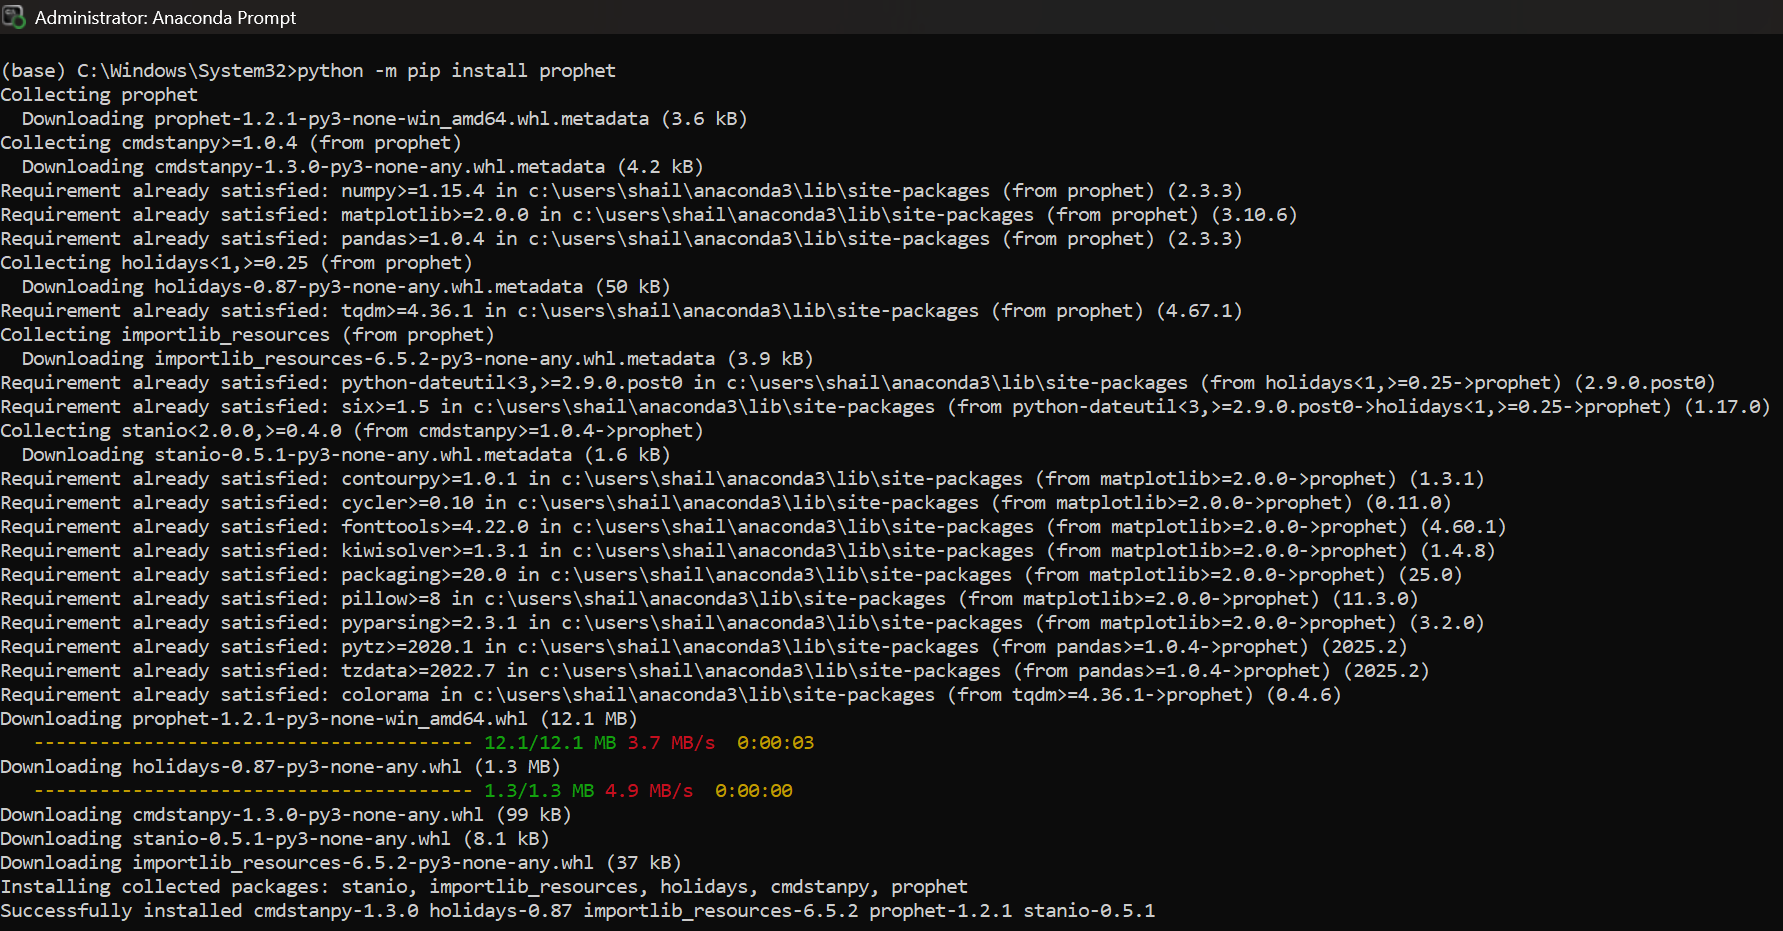

### Importing Prophet:

In [1]:
from prophet import Prophet

#### Example Code of using Prophet:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##### Data:

In [3]:
# Generating Synthetic Data:

dates = pd.date_range(start= '2020-01-10',
                     periods= 365 * 2, # For 2 Years
                     freq= 'D')

# Trend: steadily increasing:
trend = np.linspace(0, 50, len(dates))

# Yearly Seasonality: Sine wave (Winter high, Summer low):
seasonal_year = 10 * np.sin(np.linspace(0, 2 * np.pi * 2, len(dates)))

# Weekly Seasonality: Simulated "Weekend Drop" (every 7th day is lower):
seasonal_week = np.array([5 if i % 7 < 5 else -5 for i in range(len(dates))])

# Noise:
noise = np.random.normal(0, 2, len(dates))

y = trend + seasonal_year + seasonal_week + noise

In [7]:
y[:10]

array([ 5.00170111,  8.27133375,  3.54788573,  4.78710912,  4.751995  ,
       -6.88661074, -5.28066573,  6.44833602,  5.63277906,  7.58876252])

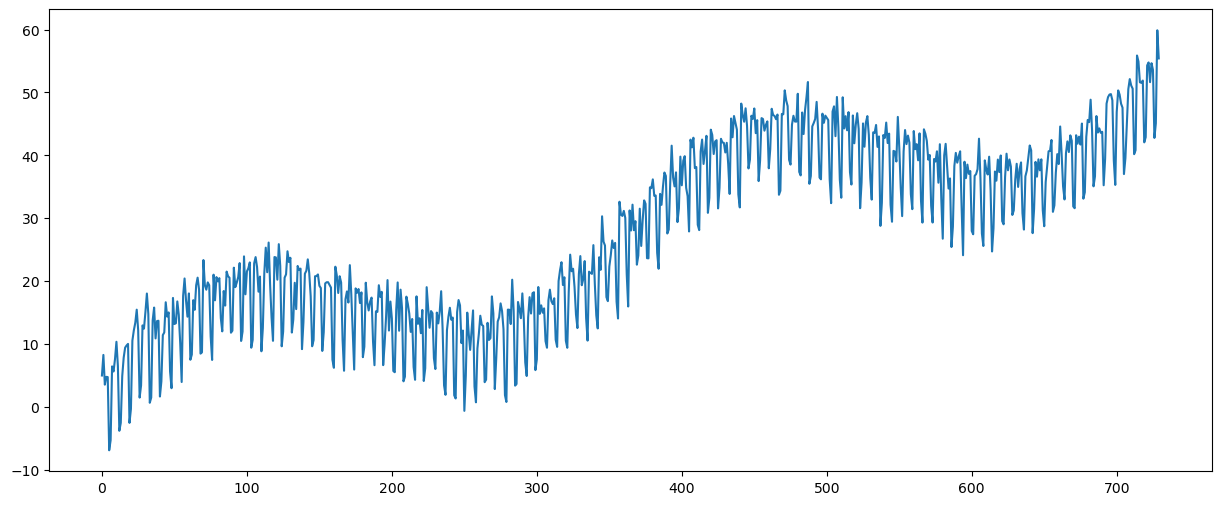

In [10]:
# Visualizing Data:

plt.figure(figsize= (15,6))
plt.plot(y)
plt.show()

##### Creating Daraframe:

In [11]:
# Create the specific dataframe format Prophet expects:
df = pd.DataFrame({'ds': dates, 'y': y})

In [12]:
df.head()

,ds,y
0,2020-01-10,5.001701
1,2020-01-11,8.271334
2,2020-01-12,3.547886
3,2020-01-13,4.787109
4,2020-01-14,4.751995


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      730 non-null    datetime64[ns]
 1   y       730 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 11.5 KB


##### Instantiate & Fit Model

In [14]:
m = Prophet(daily_seasonality= False, 
            yearly_seasonality= True, 
            weekly_seasonality= True)

m.fit(df)

18:48:59 - cmdstanpy - INFO - Chain [1] start processing
18:49:00 - cmdstanpy - INFO - Chain [1] done processing


##### Creating Future Dataframe

In [15]:
# This is a key Prophet step. You create a blank dataframe extending into the futur

future = m.make_future_dataframe(periods= 90)

In [17]:
future.head()

,ds
0,2020-01-10
1,2020-01-11
2,2020-01-12
3,2020-01-13
4,2020-01-14


##### Forecast

In [18]:
forecast = m.predict(future)

In [19]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-10,1.864046,2.150023,7.203560,1.864046,1.864046,2.907553,2.907553,2.907553,3.002041,3.002041,3.002041,-0.094488,-0.094488,-0.094488,0.0,0.0,0.0,4.771599
1,2020-01-11,1.935091,2.083740,7.158562,1.935091,1.935091,2.730015,2.730015,2.730015,2.680930,2.680930,2.680930,0.049086,0.049086,0.049086,0.0,0.0,0.0,4.665106
2,2020-01-12,2.006135,2.426982,7.451604,2.006135,2.006135,2.970940,2.970940,2.970940,2.775953,2.775953,2.775953,0.194988,0.194988,0.194988,0.0,0.0,0.0,4.977075
3,2020-01-13,2.077179,3.135600,8.181508,2.077179,2.077179,3.547159,3.547159,3.547159,3.202645,3.202645,3.202645,0.344514,0.344514,0.344514,0.0,0.0,0.0,5.624338
4,2020-01-14,2.148224,2.820812,7.826473,2.148224,2.148224,3.154288,3.154288,3.154288,2.655395,2.655395,2.655395,0.498893,0.498893,0.498893,0.0,0.0,0.0,5.302511


In [21]:
forecast[['yhat', 'yhat_lower', 'yhat_upper']].head()

,yhat,yhat_lower,yhat_upper
0,4.771599,2.150023,7.203560
1,4.665106,2.083740,7.158562
2,4.977075,2.426982,7.451604
3,5.624338,3.135600,8.181508
4,5.302511,2.820812,7.826473


##### Visualization

<Figure size 1500x600 with 0 Axes>

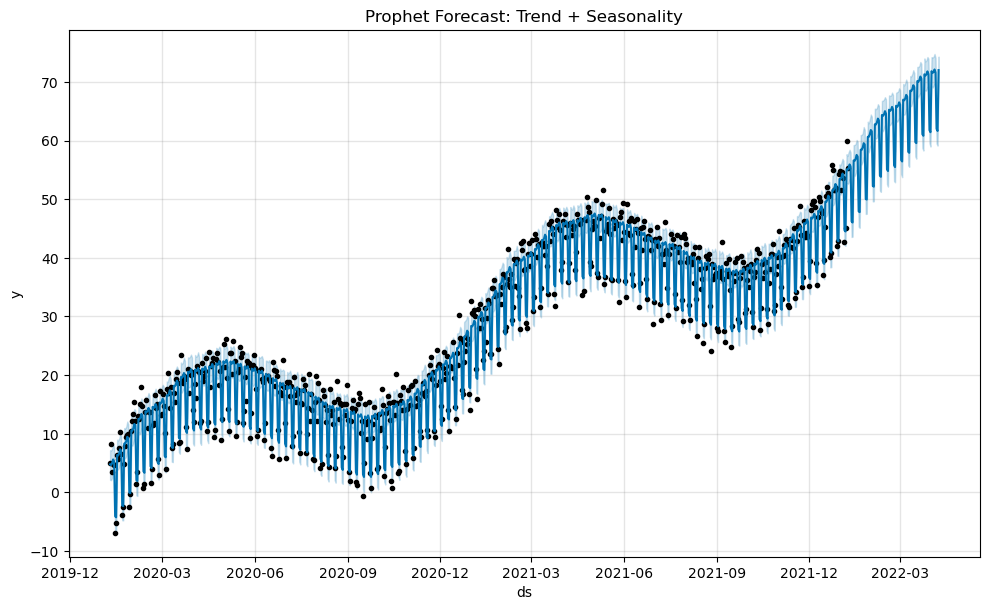

In [23]:
plt.figure(figsize= (15,6))
fig1 = m.plot(forecast)
plt.title('Prophet Forecast: Trend + Seasonality')
plt.show()

<Figure size 1500x600 with 0 Axes>

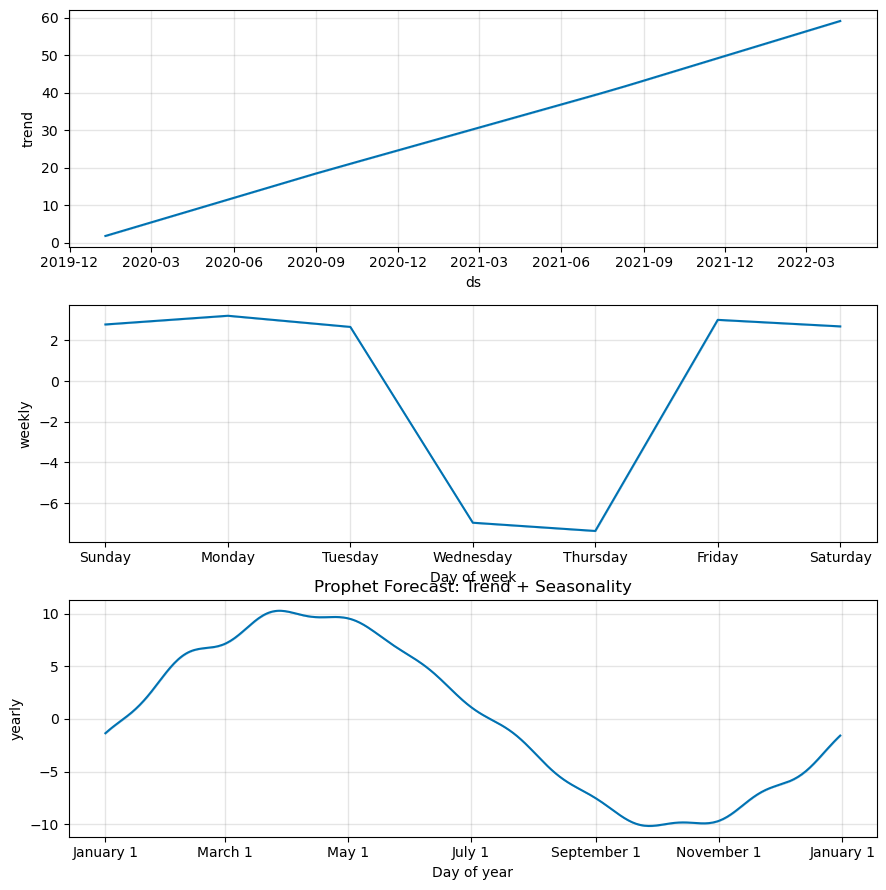

In [24]:
plt.figure(figsize= (15,6))
fig2 = m.plot_components(forecast)
plt.title('Prophet Forecast: Trend + Seasonality')
plt.show()